In [ ]:
from google.colab import files
uploaded = files.upload()

Saving All in one .xlsx to All in one .xlsx


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import joblib
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, GaussianNoise
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =================================================================
# 1. DATA LOADING & THIESSEN WEIGHTS
# =================================================================
df = pd.read_excel('All in one .xlsx')
# Fix Excel Date integers
df['Date'] = pd.to_datetime(df['Date'], unit='D', origin='1899-12-30')
df = df.sort_values('Date').set_index('Date')

# Target Log-Transform ()
df['Streamflow_Log'] = np.log1p(df['Streamflow'])

# STATION GROUPS
precip_cols = ['Akaki_Precip', 'Bishoftu_Precip', 'Bole_Precip', 'Ginchi_Precip', 'Hombole_Precip', 'Mojo_Precip', 'Obs_Precip', 'Sendafa_Precip']
tmax_cols = ['Bishoftu_Temp_Max', 'Bole_Temp_Max', 'Mojo_Temp_Max', 'Obs_Temp_Max']
tmin_cols = ['Bishoftu_Temp_Min', 'Bole_Temp_Min', 'Mojo_Temp_Min', 'Obs_Temp_Min']

# THIESSEN WEIGHTS (Based on your calculated normalized values)
weights = {
    'Akaki_Precip': 0.1379, 'Bishoftu_Precip': 0.1149, 'Bole_Precip': 0.0920,
    'Ginchi_Precip': 0.1724, 'Hombole_Precip': 0.2299, 'Mojo_Precip': 0.1149, 'Obs_Precip': 0.1379
}

In [ ]:
print(f"Minimum Date: {df.index.min()}")
print(f"Maximum Date: {df.index.max()}")
print(f"Number of unique dates: {df.index.nunique()}")
print(f"Number of null dates: {df.index.isnull().sum()}")

Minimum Date: 1985-01-01 00:00:00
Maximum Date: 2022-12-31 00:00:00
Number of unique dates: 13879
Number of null dates: 0


In [ ]:
# =================================================================
# 2. FEATURE ENGINEERING
# =================================================================
input_features = precip_cols + tmax_cols + tmin_cols

# A. Station-level 7-day rolling
for p in precip_cols:
    df[f'{p}_roll7'] = df[p].rolling(window=7).mean().fillna(0)
    input_features.append(f'{p}_roll7')

# B. Basin-wide Memory (Using THIESSEN WEIGHTS instead of arithmetic average)
# This makes your Basin_P features more accurate for a large catchment
df['Weighted_P'] = sum(df[col] * weights.get(col, 0) for col in precip_cols)
df['Basin_P_30day'] = df['Weighted_P'].rolling(window=30).mean().fillna(0)
input_features.append('Basin_P_30day')
df['Basin_P_60day'] = df['Weighted_P'].rolling(window=60).mean().fillna(0)
df['P_rolling_90'] = df['Weighted_P'].rolling(window=90).mean().fillna(0)
input_features.append('Basin_P_60day')
input_features.append('P_rolling_90')

# C. Seasonality (Sine/Cosine) - Helps R2
df['sin_doy'] = np.sin(2 * np.pi * df.index.dayofyear / 365.25)
df['cos_doy'] = np.cos(2 * np.pi * df.index.dayofyear / 365.25)
input_features.extend(['sin_doy', 'cos_doy'])

# D. Add Lagged Streamflow_Log as a powerful predictor
# These lagged values provide the model with direct information about recent flow conditions.
for lag in [1, 7, 30]: # Lags for 1 day, 1 week, and 1 month
    df[f'Streamflow_Log_Lag{lag}'] = df['Streamflow_Log'].shift(lag)
    input_features.append(f'Streamflow_Log_Lag{lag}')

df_clean = df[input_features + ['Streamflow_Log', 'Streamflow']].interpolate().bfill()


In [ ]:
# =================================================================
# 3. SCALING & SEQUENCING
# =================================================================
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

scaled_x = scaler_x.fit_transform(df_clean[input_features])
scaled_y = scaler_y.fit_transform(df_clean[['Streamflow_Log']])

WINDOW_SIZE = 90 # capturing 3 months of memory

def create_sequences(data_x, data_y, window_size):
    X, y = [], []
    for i in range(len(data_x) - window_size):
        X.append(data_x[i : i + window_size])
        y.append(data_y[i + window_size])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_x, scaled_y, WINDOW_SIZE)

# 70/15/15 Split
train_end = int(len(X) * 0.70)
val_end = int(len(X) * 0.85)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

In [ ]:
from tensorflow.keras.layers import GaussianNoise, BatchNormalization
from tensorflow.keras.regularizers import l2

# --- THE "GENERALIZER" ARCHITECTURE (To close the Gap) ---
model = Sequential([
    Input(shape=(90, len(input_features))),

    # 1. Add Input Noise (Stops the model from memorizing specific station values)
    GaussianNoise(0.01),

    # 2. Smaller LSTM layers (Simpler models generalize better to the Test set)

    LSTM(128, return_sequences=True, kernel_regularizer=l2(0.002), recurrent_regularizer=l2(0.002)),
    BatchNormalization(),
    Dropout(0.3),

    LSTM(64, return_sequences=False, kernel_regularizer=l2(0.002)),
    BatchNormalization(),
    Dropout(0.3),

    # Dense Layer for feature refinement
    Dense(16, activation='relu', kernel_regularizer=l2(0.002)),
    Dense(1)
])

# Use a slightly slower learning rate for better stability
model.compile(optimizer=tf.keras.optimizers.Nadam(learning_rate=0.0008),
              loss=tf.keras.losses.Huber(delta=1.5))

In [ ]:

# 1. Get the physical streamflow values for the training set
train_physical_flow = df_clean['Streamflow'].iloc[WINDOW_SIZE : train_end + WINDOW_SIZE].values

# 2. Calculate weights: We use a linear weight
# Linear Weight
sample_weights = train_physical_flow + 1.0


# 3. Normalize the weights
sample_weights = sample_weights / np.mean(sample_weights)

print("Weight for min flow day:", np.min(sample_weights))
print("Weight for max flow day:", np.max(sample_weights))

Weight for min flow day: 0.05896614527284333
Weight for max flow day: 17.9882981760223


In [ ]:
# Define callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_loss', mode='min')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)

# The 'sample_weights' variable from the previous cell (UcGwhBHRiiwS)
# already has the correct number of samples for the training set.
history = model.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=40,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

Epoch 1/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - loss: 0.8117 - val_loss: 0.5871 - learning_rate: 8.0000e-04
Epoch 2/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.4930 - val_loss: 0.4063 - learning_rate: 8.0000e-04
Epoch 3/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.3428 - val_loss: 0.3064 - learning_rate: 8.0000e-04
Epoch 4/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.2483 - val_loss: 0.2228 - learning_rate: 8.0000e-04
Epoch 5/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1843 - val_loss: 0.1618 - learning_rate: 8.0000e-04
Epoch 6/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1392 - val_loss: 0.1202 - learning_rate: 8.0000e-04
Epoch 7/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1055 - val_loss: 0.0904 - learning_rate: 8.0000e-04
Epoch 8/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0814 - val_loss: 0.0695 - learning_rate: 8.0000e-04
Epoch 9/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0631 - 

In [ ]:
# 6. MODIFIED EVALUATION (DUAN'S SMEARING BCF)
# =================================================================
def get_final_physical_metrics(X_data, y_true_scaled, model, s_y, bcf_val=None):
    # 1. Predictions in Log-space
    preds_scaled = model.predict(X_data, verbose=0)
    true_log = s_y.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
    pred_log = s_y.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()

    # --- MODIFIED BCF LOGIC (Duan's Smearing Method) ---
    # This method naturally "Heads Up" the volume by accounting for residual variance
    if bcf_val is None:
        residuals_log = true_log - pred_log
        bcf_val = np.mean(np.exp(residuals_log))
        print(f"Calculated Smearing BCF: {bcf_val:.4f}")

    # 2. Back-transform to physical units (m3/s)
    # Q_phys = exp(log_pred) * BCF - 1
    p_phys_final = np.exp(pred_log) * bcf_val - 1
    t_phys = np.expm1(true_log)

    # 3. Metrics
    nse = 1 - (np.sum((t_phys - p_phys_final)**2) / np.sum((t_phys - np.mean(t_phys))**2))
    corr, _ = pearsonr(t_phys, p_phys_final)
    pbias = (np.sum(t_phys - p_phys_final) * 100) / np.sum(t_phys)
    mae = mean_absolute_error(t_phys, p_phys_final)
    rmse = np.sqrt(mean_squared_error(t_phys, p_phys_final))

    return [np.mean(t_phys), np.max(t_phys), np.max(p_phys_final), mae, rmse, nse, corr**2, pbias], bcf_val

# --- FINAL OUTPUT ---
train_res, bcf_final = get_final_physical_metrics(X_train, y_train, model, scaler_y)
val_res, _ = get_final_physical_metrics(X_val, y_val, model, scaler_y, bcf_val=bcf_final)
test_res, _ = get_final_physical_metrics(X_test, y_test, model, scaler_y, bcf_val=bcf_final)

results_table = pd.DataFrame({
    'Metric': ['Mean Flow', 'Obs Max', 'Pred Max', 'MAE', 'RMSE', 'NSE', 'R2', 'PBIAS'],
    'Train': train_res, 'Val': val_res, 'Test': test_res
})

print("\n--- FINAL CORRECTED PERFORMANCE (m3/s) ---")
print(results_table.round(3).to_string(index=False))
print(f"\nFinal Bias Correction Factor used: {bcf_final:.4f}")

Calculated Smearing BCF: 0.9438

--- FINAL CORRECTED PERFORMANCE (m3/s) ---
   Metric   Train     Val    Test
Mean Flow  43.704  37.339  64.478
  Obs Max 803.142 478.952 553.237
 Pred Max 419.564 316.234 399.921
      MAE  10.733  10.829  19.019
     RMSE  27.720  27.688  43.959
      NSE   0.874   0.819   0.806
       R2   0.890   0.823   0.825
    PBIAS   6.977   2.786  11.640

Final Bias Correction Factor used: 0.9438


In [ ]:
import joblib

# 1. Save the Keras Model
model.save('upper_awash_lstm_final3_model.keras')

# 2. Save the Scalers (You need these to transform future climate data)
joblib.dump(scaler_x, 'scaler_x3.pkl')
joblib.dump(scaler_y, 'scaler_y3.pkl')

# 3. Save the list of features so you remember the order
import json
with open('features_list.json', 'w') as f:
    json.dump(input_features, f)

print("Model and Scalers saved successfully! Keep these files safe for your climate projections.")

Model and Scalers saved successfully! Keep these files safe for your climate projections.


Part 1: Setup and Data Preparation

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Set professional style
plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({'font.size': 12, 'figure.dpi': 300, 'savefig.dpi': 300})

def get_physical_flow(X_data, y_true_scaled, model, s_y, train_CF):
    preds_scaled = model.predict(X_data, verbose=0)
    true_log = s_y.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
    pred_log = s_y.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
    return np.expm1(true_log), np.expm1(pred_log) * train_CF

# Get values for all sets
y_train_true, y_train_pred = get_physical_flow(X_train, y_train, model, scaler_y, bcf_final)
y_val_true, y_val_pred = get_physical_flow(X_val, y_val, model, scaler_y, bcf_final)
y_test_true, y_test_pred = get_physical_flow(X_test, y_test, model, scaler_y, bcf_final)


Part 2: Figure 1 - Model Training History (Loss Curve)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

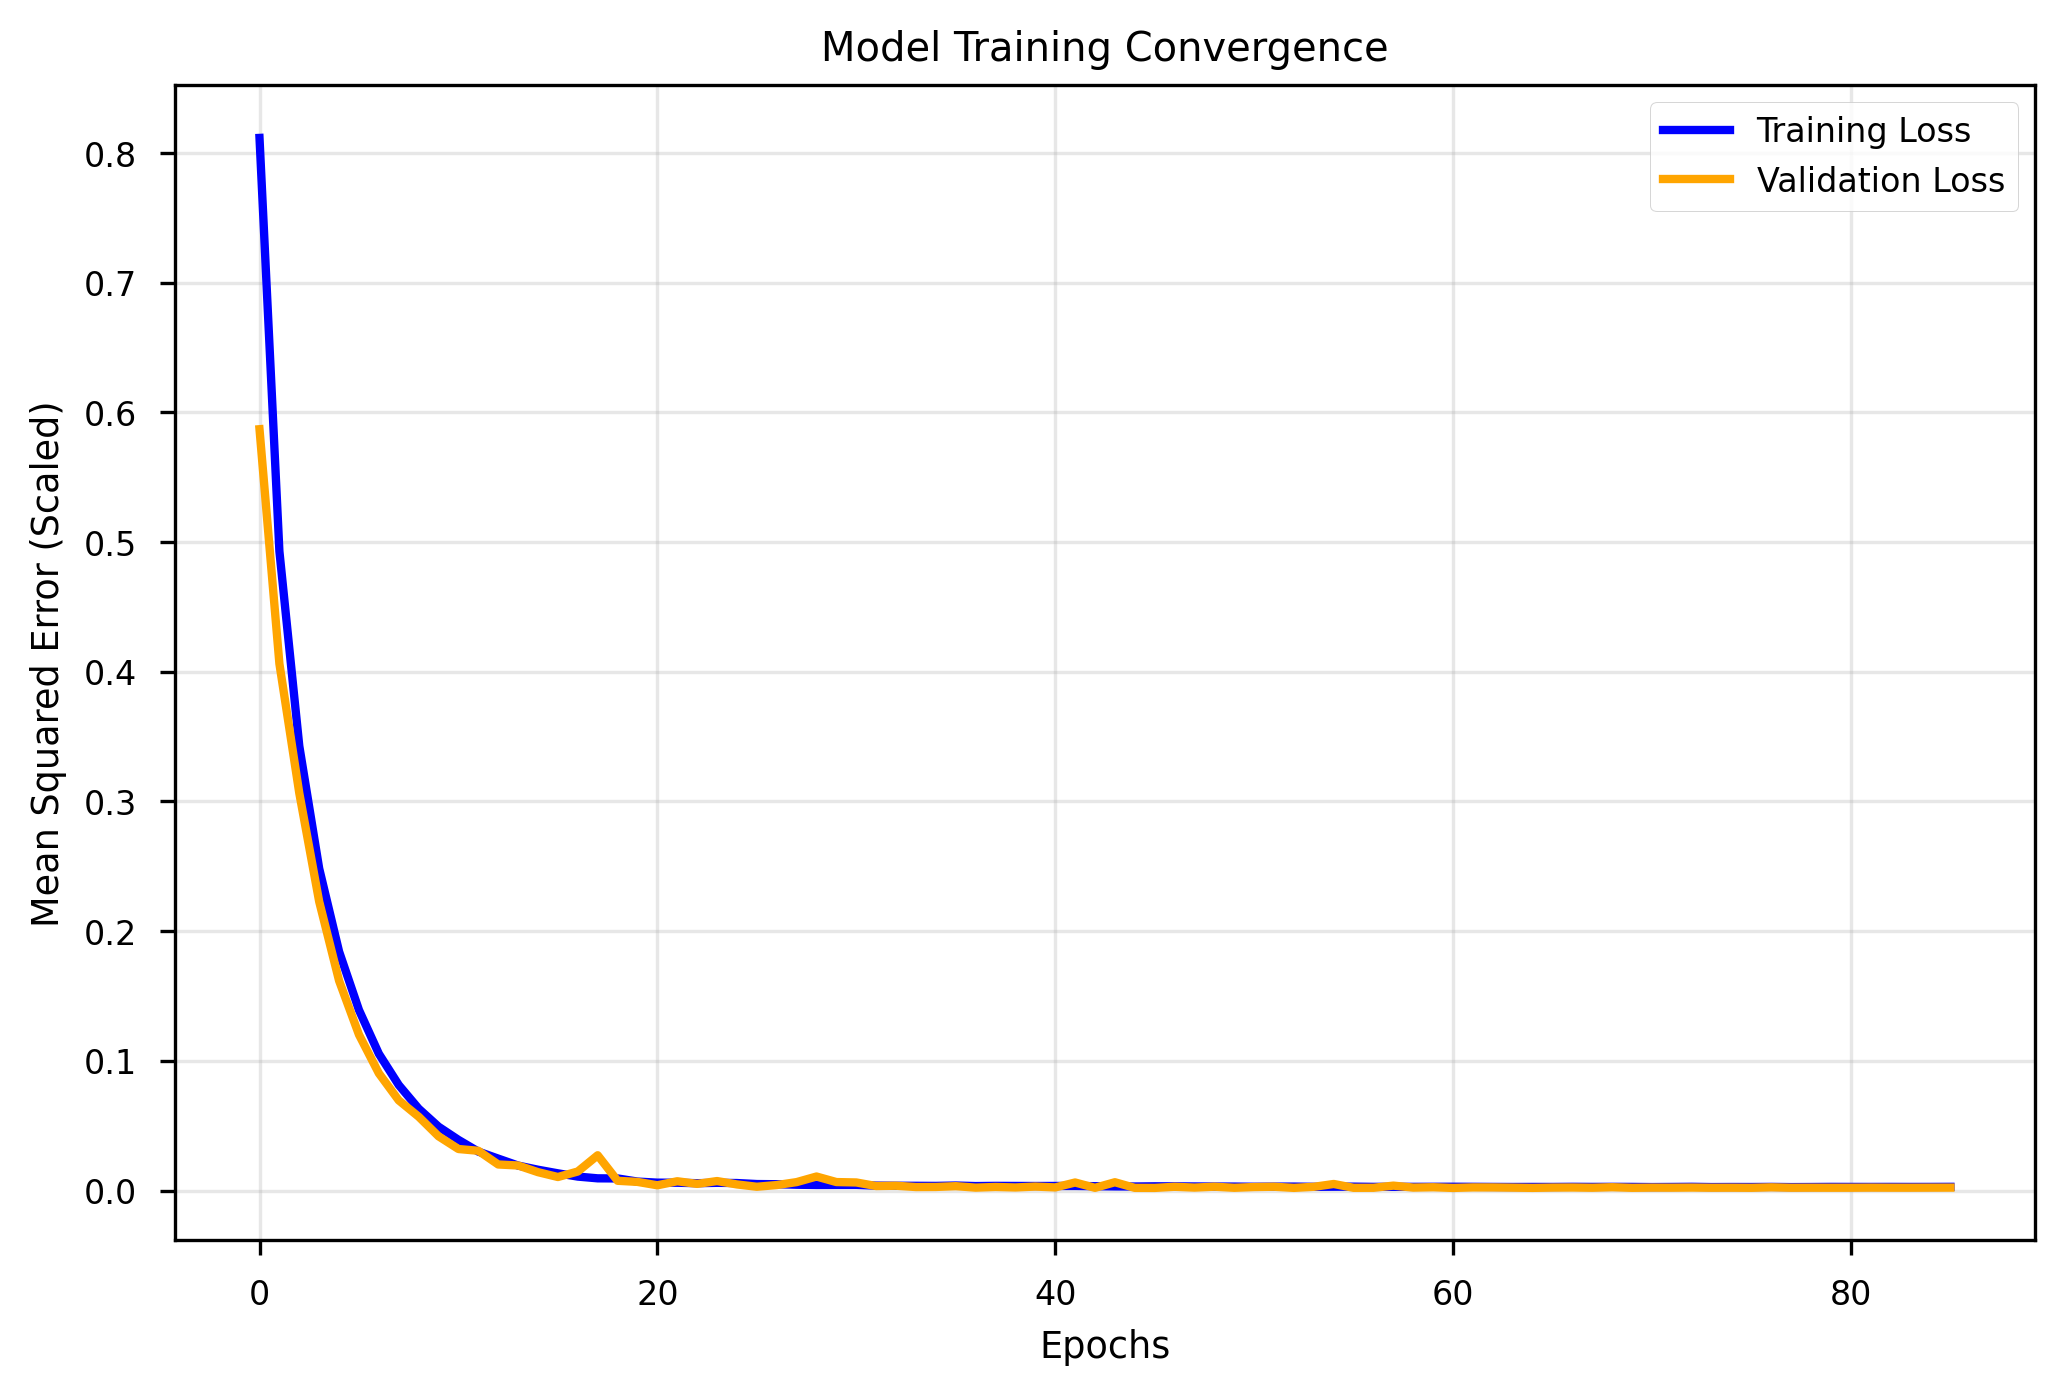

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('Model Training Convergence')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (Scaled)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('Figure1_Training_final awash3_History.png')
files.download('Figure1_Training_final awash3_History.png')
plt.show()

Part 3: Figure 2 - Combined Hydrographs (Time-Series)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

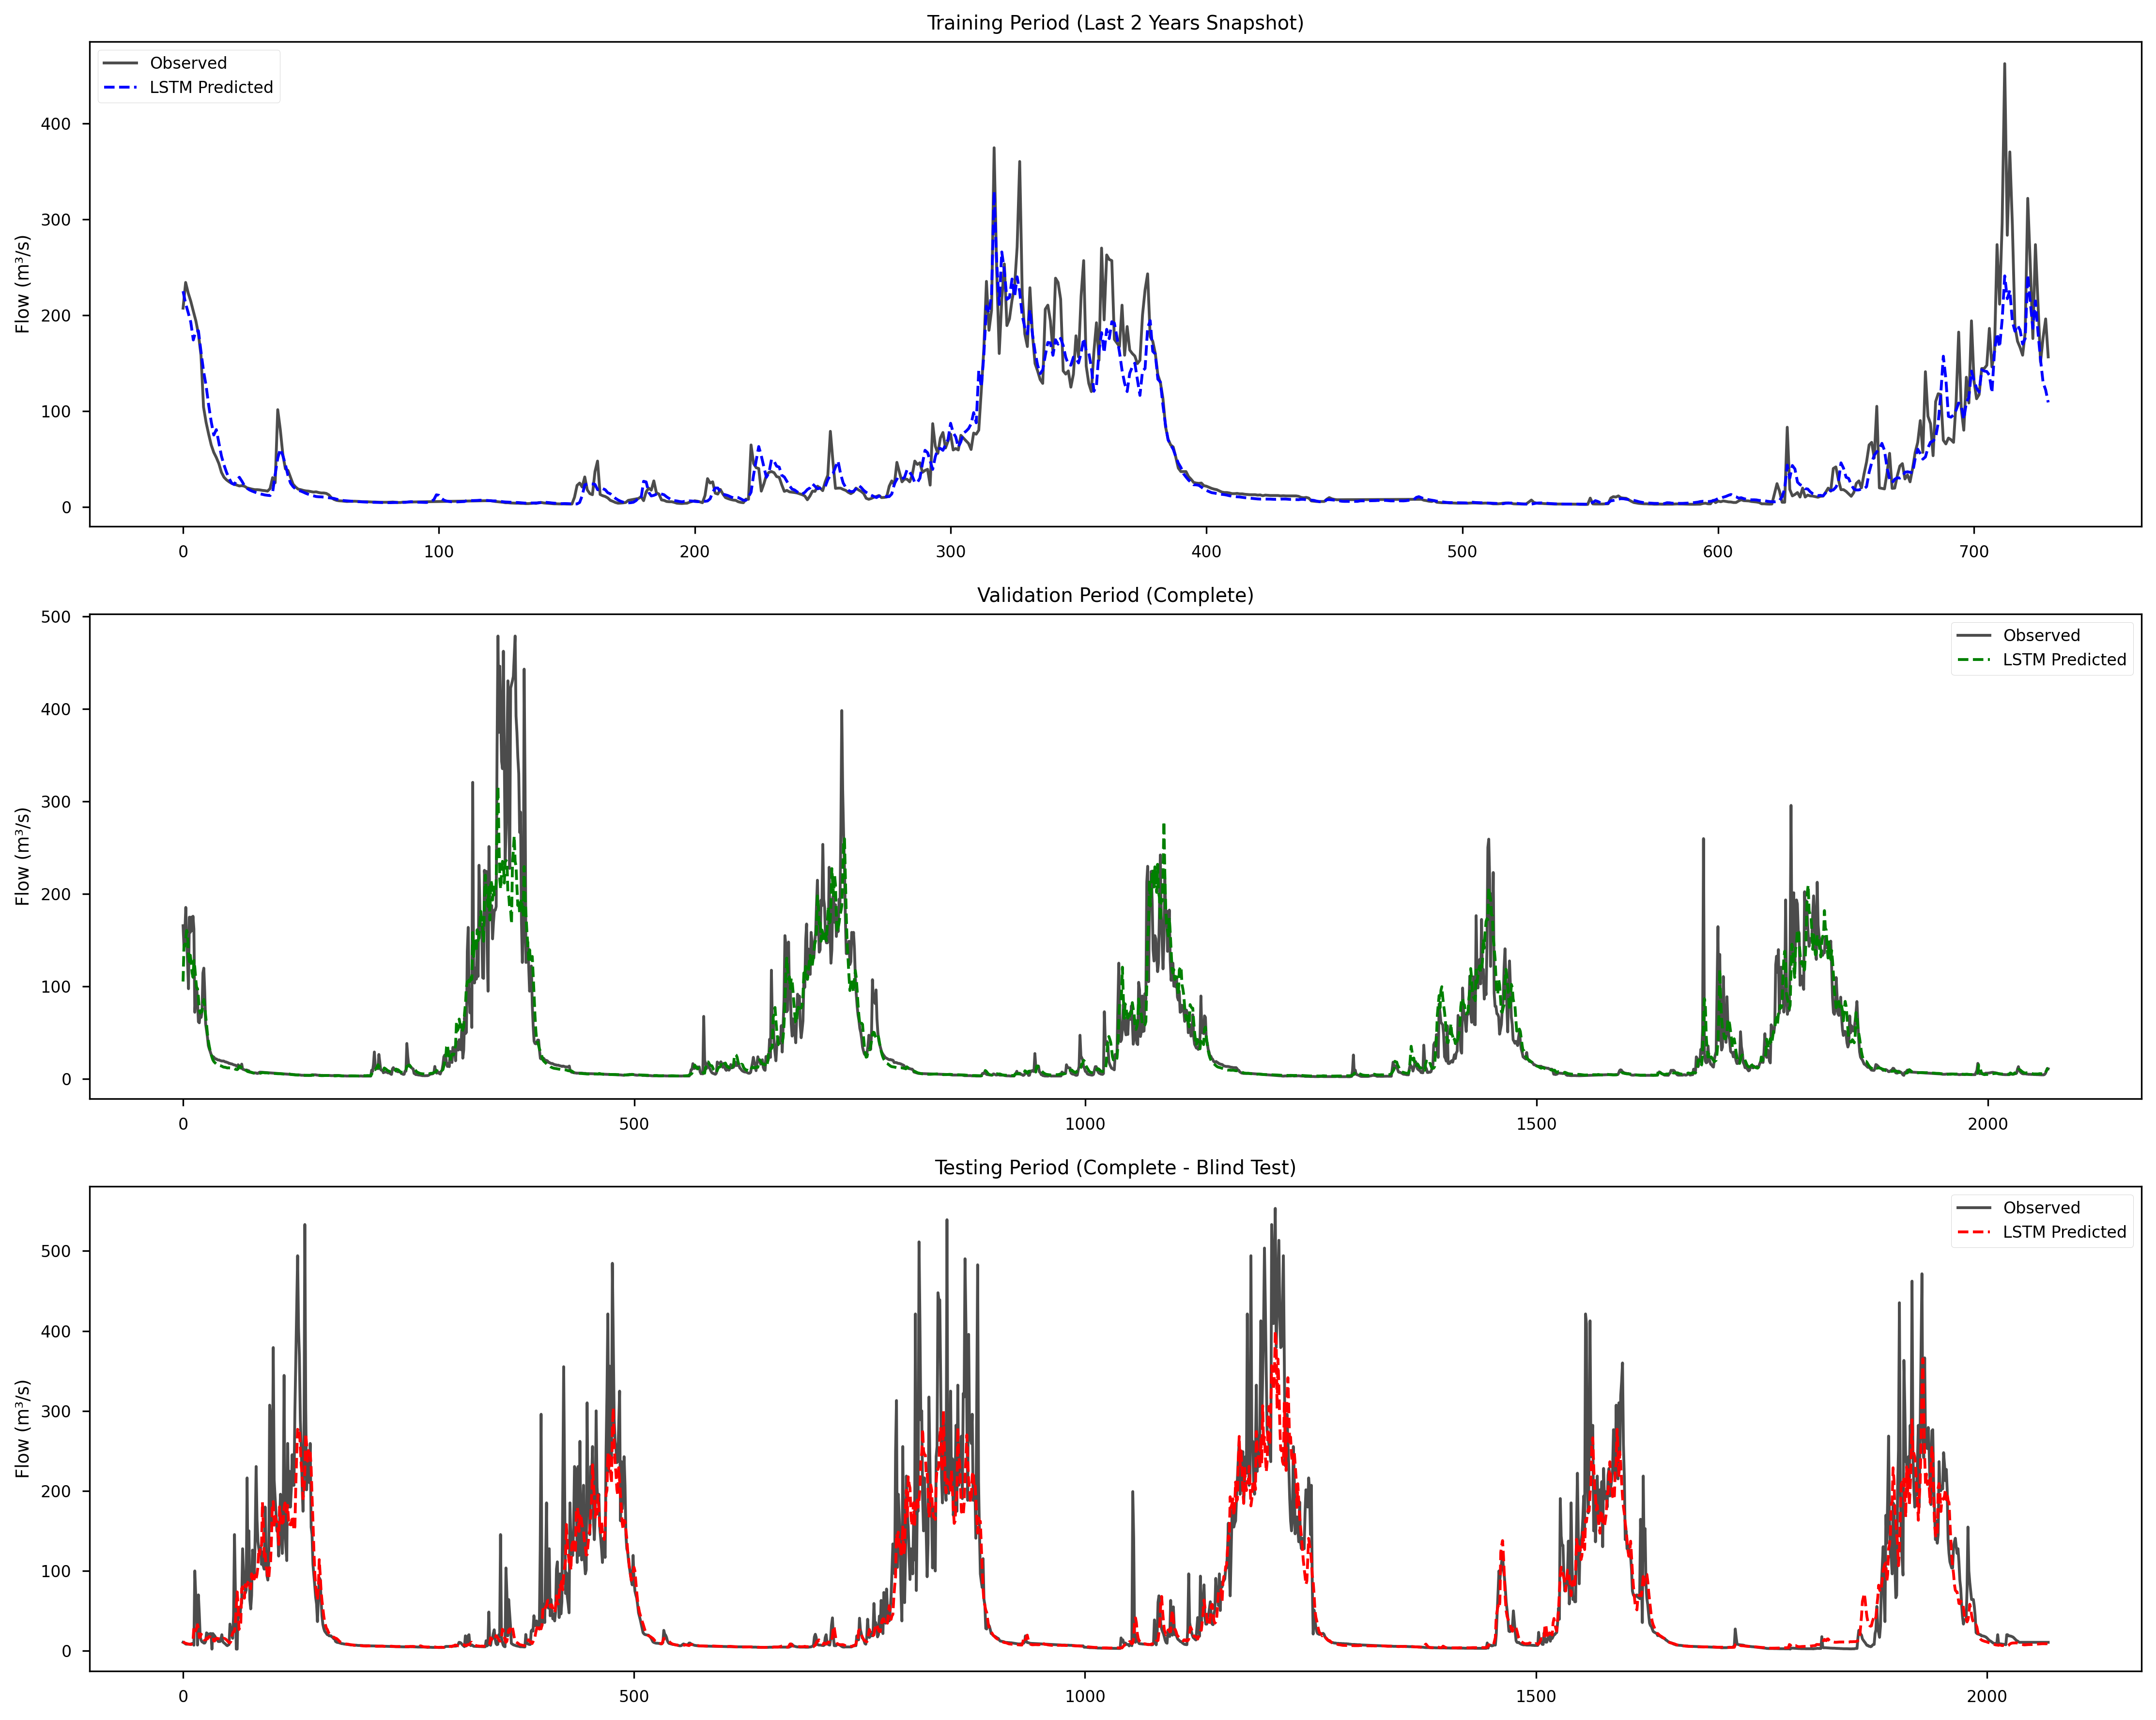

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=False)

# 1. Training Snapshot (Last 730 days of training)
axes[0].plot(y_train_true[-730:], label='Observed', color='black', alpha=0.7)
axes[0].plot(y_train_pred[-730:], label='LSTM Predicted', color='blue', linestyle='--')
axes[0].set_title('Training Period (Last 2 Years Snapshot)')
axes[0].set_ylabel('Flow (m³/s)')
axes[0].legend()

# 2. Validation Set
axes[1].plot(y_val_true, label='Observed', color='black', alpha=0.7)
axes[1].plot(y_val_pred, label='LSTM Predicted', color='green', linestyle='--')
axes[1].set_title('Validation Period (Complete)')
axes[1].set_ylabel('Flow (m³/s)')
axes[1].legend()

# 3. Test Set
axes[2].plot(y_test_true, label='Observed', color='black', alpha=0.7)
axes[2].plot(y_test_pred, label='LSTM Predicted', color='red', linestyle='--')
axes[2].set_title('Testing Period (Complete - Blind Test)')
axes[2].set_ylabel('Flow (m³/s)')
axes[2].legend()

plt.tight_layout()
plt.savefig('Figure2_Hydrographs_final3 awash.png')
files.download('Figure2_Hydrographs_final3 awash.png')
plt.show()

Part 4: Figure 3 - Scatter Plots (Correlation

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

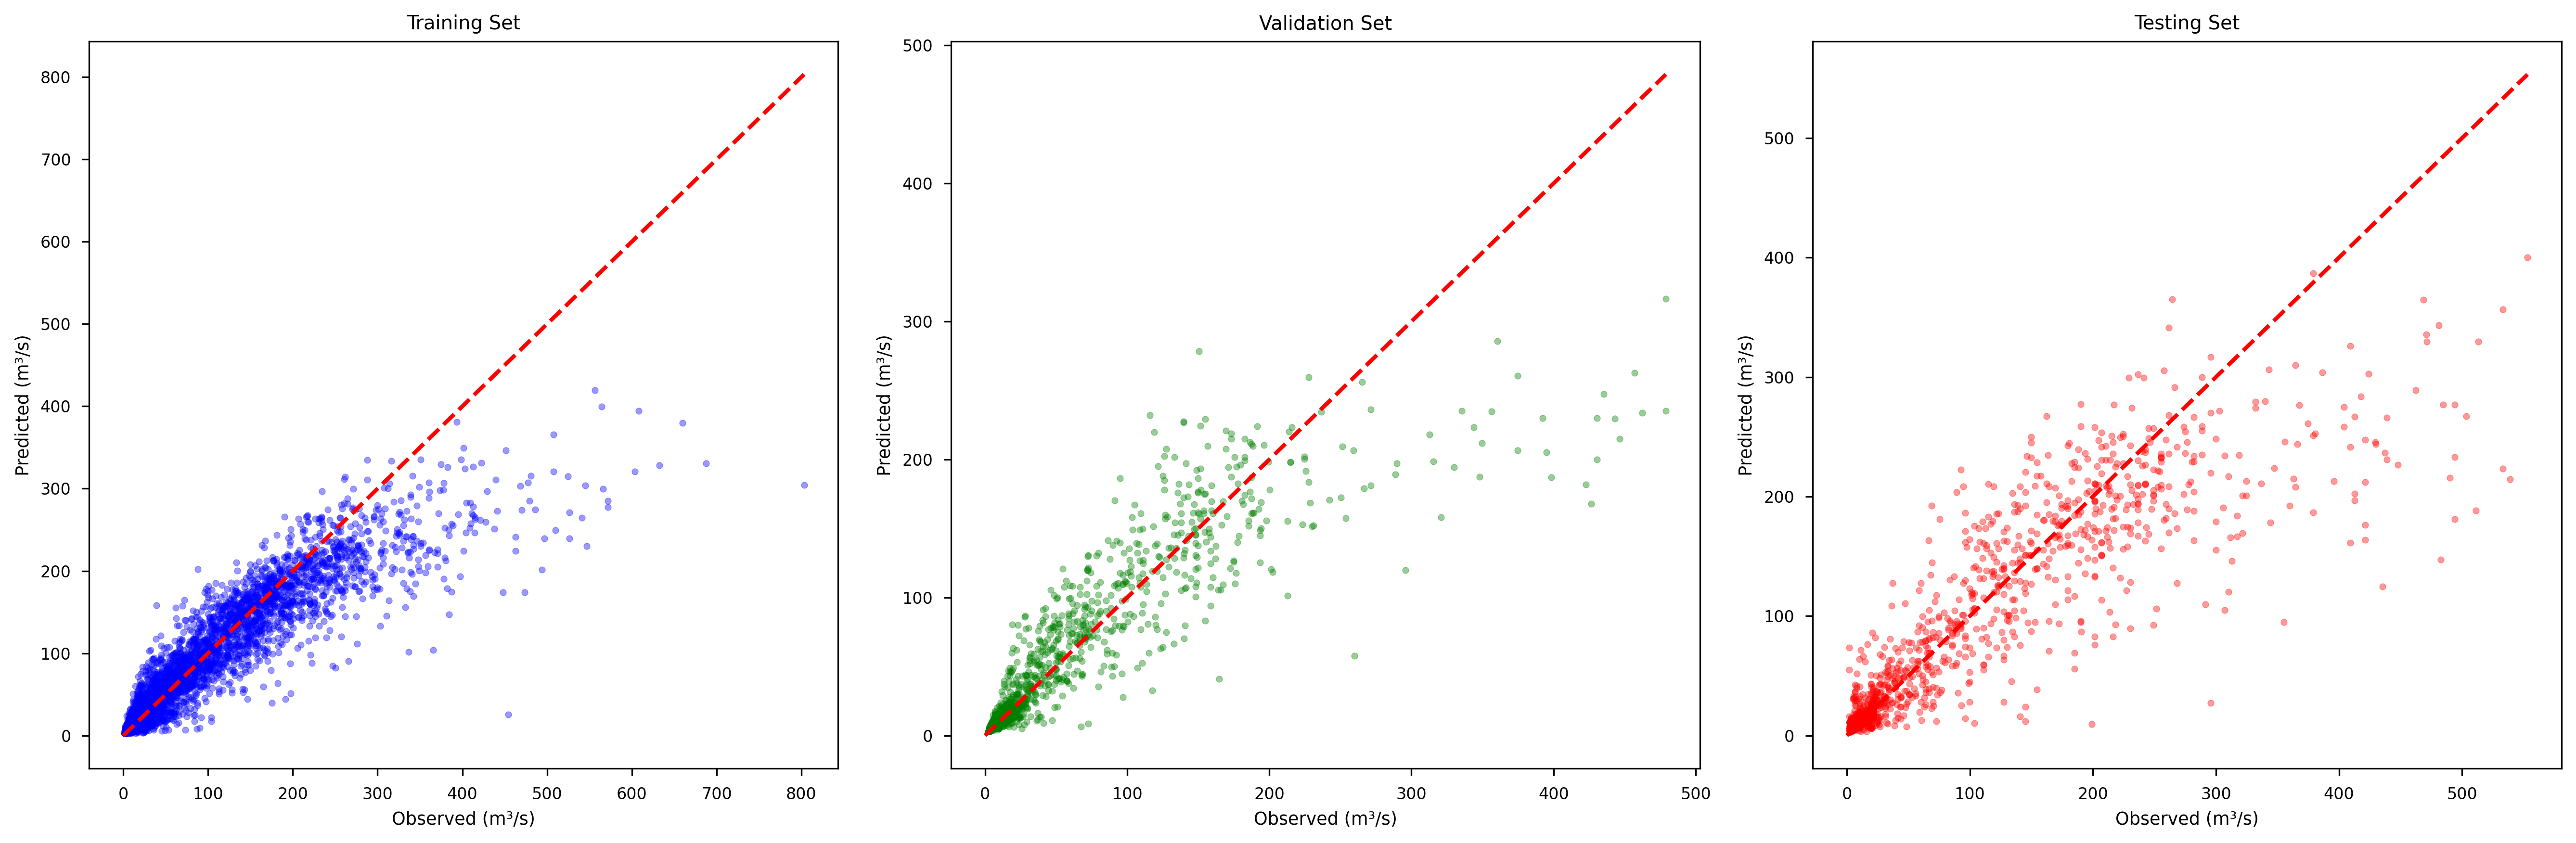

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

def plot_scatter(ax, true, pred, title, color):
    ax.scatter(true, pred, alpha=0.4, s=10, color=color)
    max_val = max(true.max(), pred.max())
    ax.plot([0, max_val], [0, max_val], 'r--', lw=2) # 1:1 Line
    ax.set_title(title)
    ax.set_xlabel('Observed (m³/s)')
    ax.set_ylabel('Predicted (m³/s)')

plot_scatter(axes[0], y_train_true, y_train_pred, 'Training Set', 'blue')
plot_scatter(axes[1], y_val_true, y_val_pred, 'Validation Set', 'green')
plot_scatter(axes[2], y_test_true, y_test_pred, 'Testing Set', 'red')

plt.tight_layout()
plt.savefig('Figure_ScatterPlots_final3 awash.png')
files.download('Figure_ScatterPlots_final3 awash.png')
plt.show()

Part 5: Figure 4 - Flow Duration Curve (FDC)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

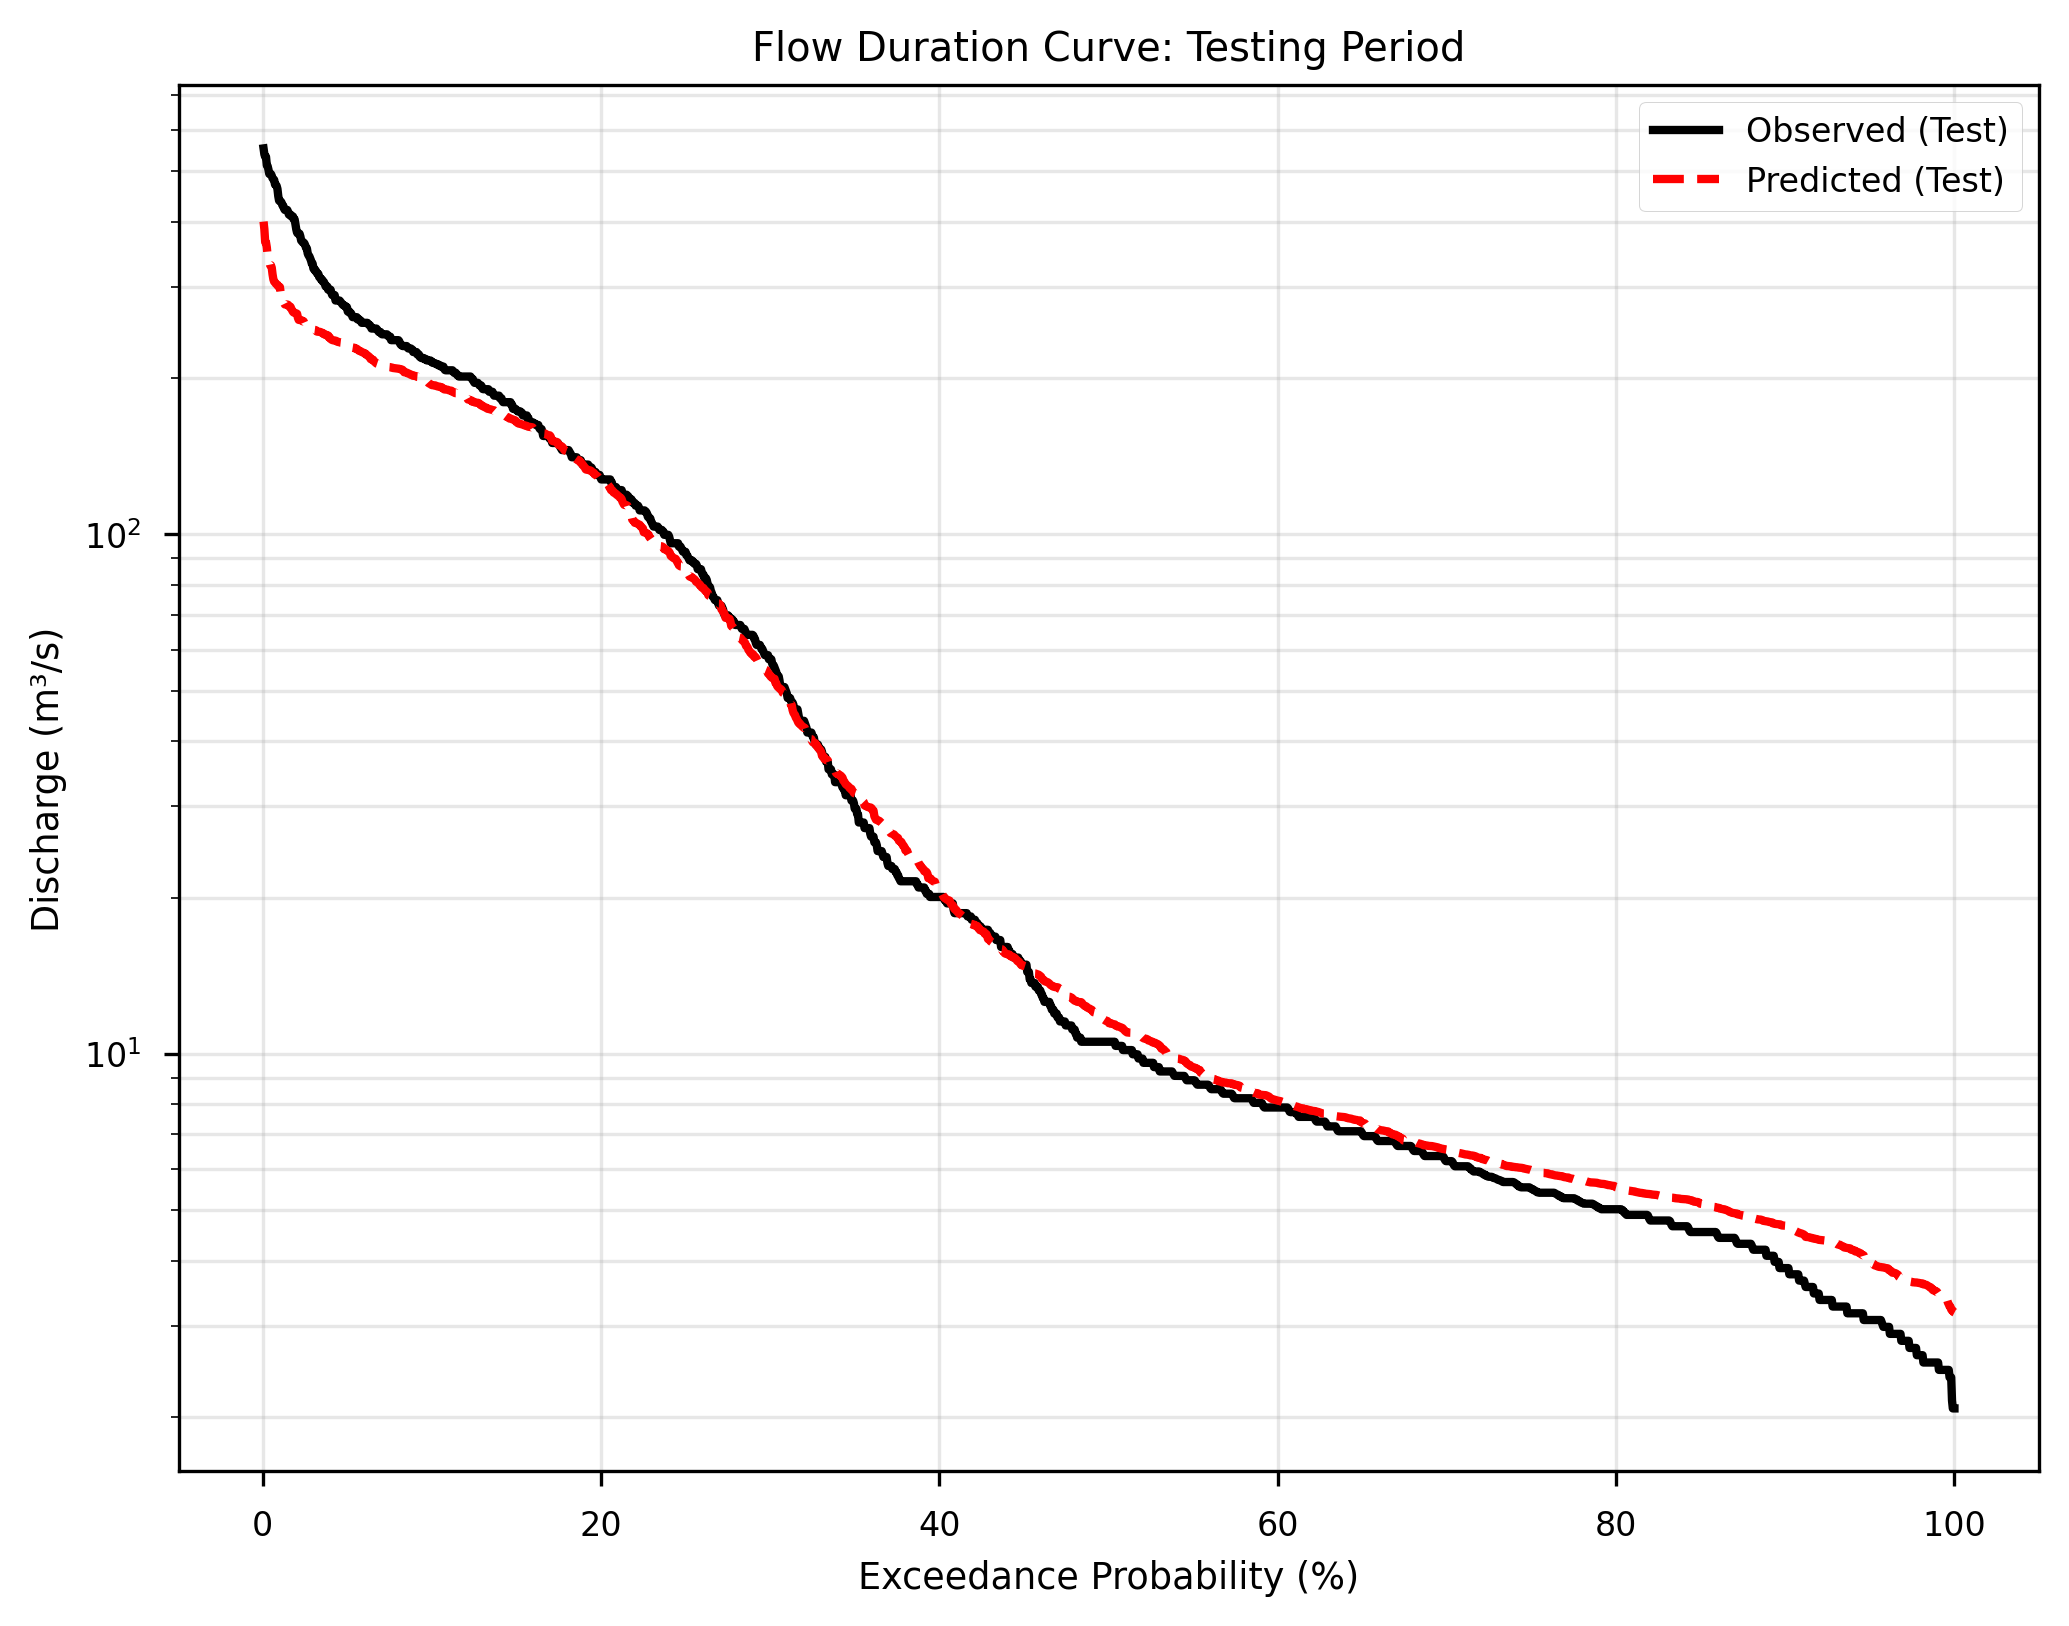

In [ ]:
def calculate_fdc(data):
    sorted_data = np.sort(data)[::-1]
    prob = np.arange(1, len(sorted_data) + 1) / len(sorted_data) * 100
    return prob, sorted_data

prob_obs, flow_obs = calculate_fdc(y_test_true)
prob_pred, flow_pred = calculate_fdc(y_test_pred)

plt.figure(figsize=(8, 6))
plt.plot(prob_obs, flow_obs, label='Observed (Test)', color='black', linewidth=2)
plt.plot(prob_pred, flow_pred, label='Predicted (Test)', color='red', linestyle='--', linewidth=2)
plt.yscale('log') # FDCs are best in Log scale
plt.xlabel('Exceedance Probability (%)')
plt.ylabel('Discharge (m³/s)')
plt.title('Flow Duration Curve: Testing Period')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.savefig('Figure_FDC_final3 awash.png')
files.download('Figure_FDC_final3 awash.png')
plt.show()